# Appendix

In [17]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import erfcx
from scipy.optimize import curve_fit

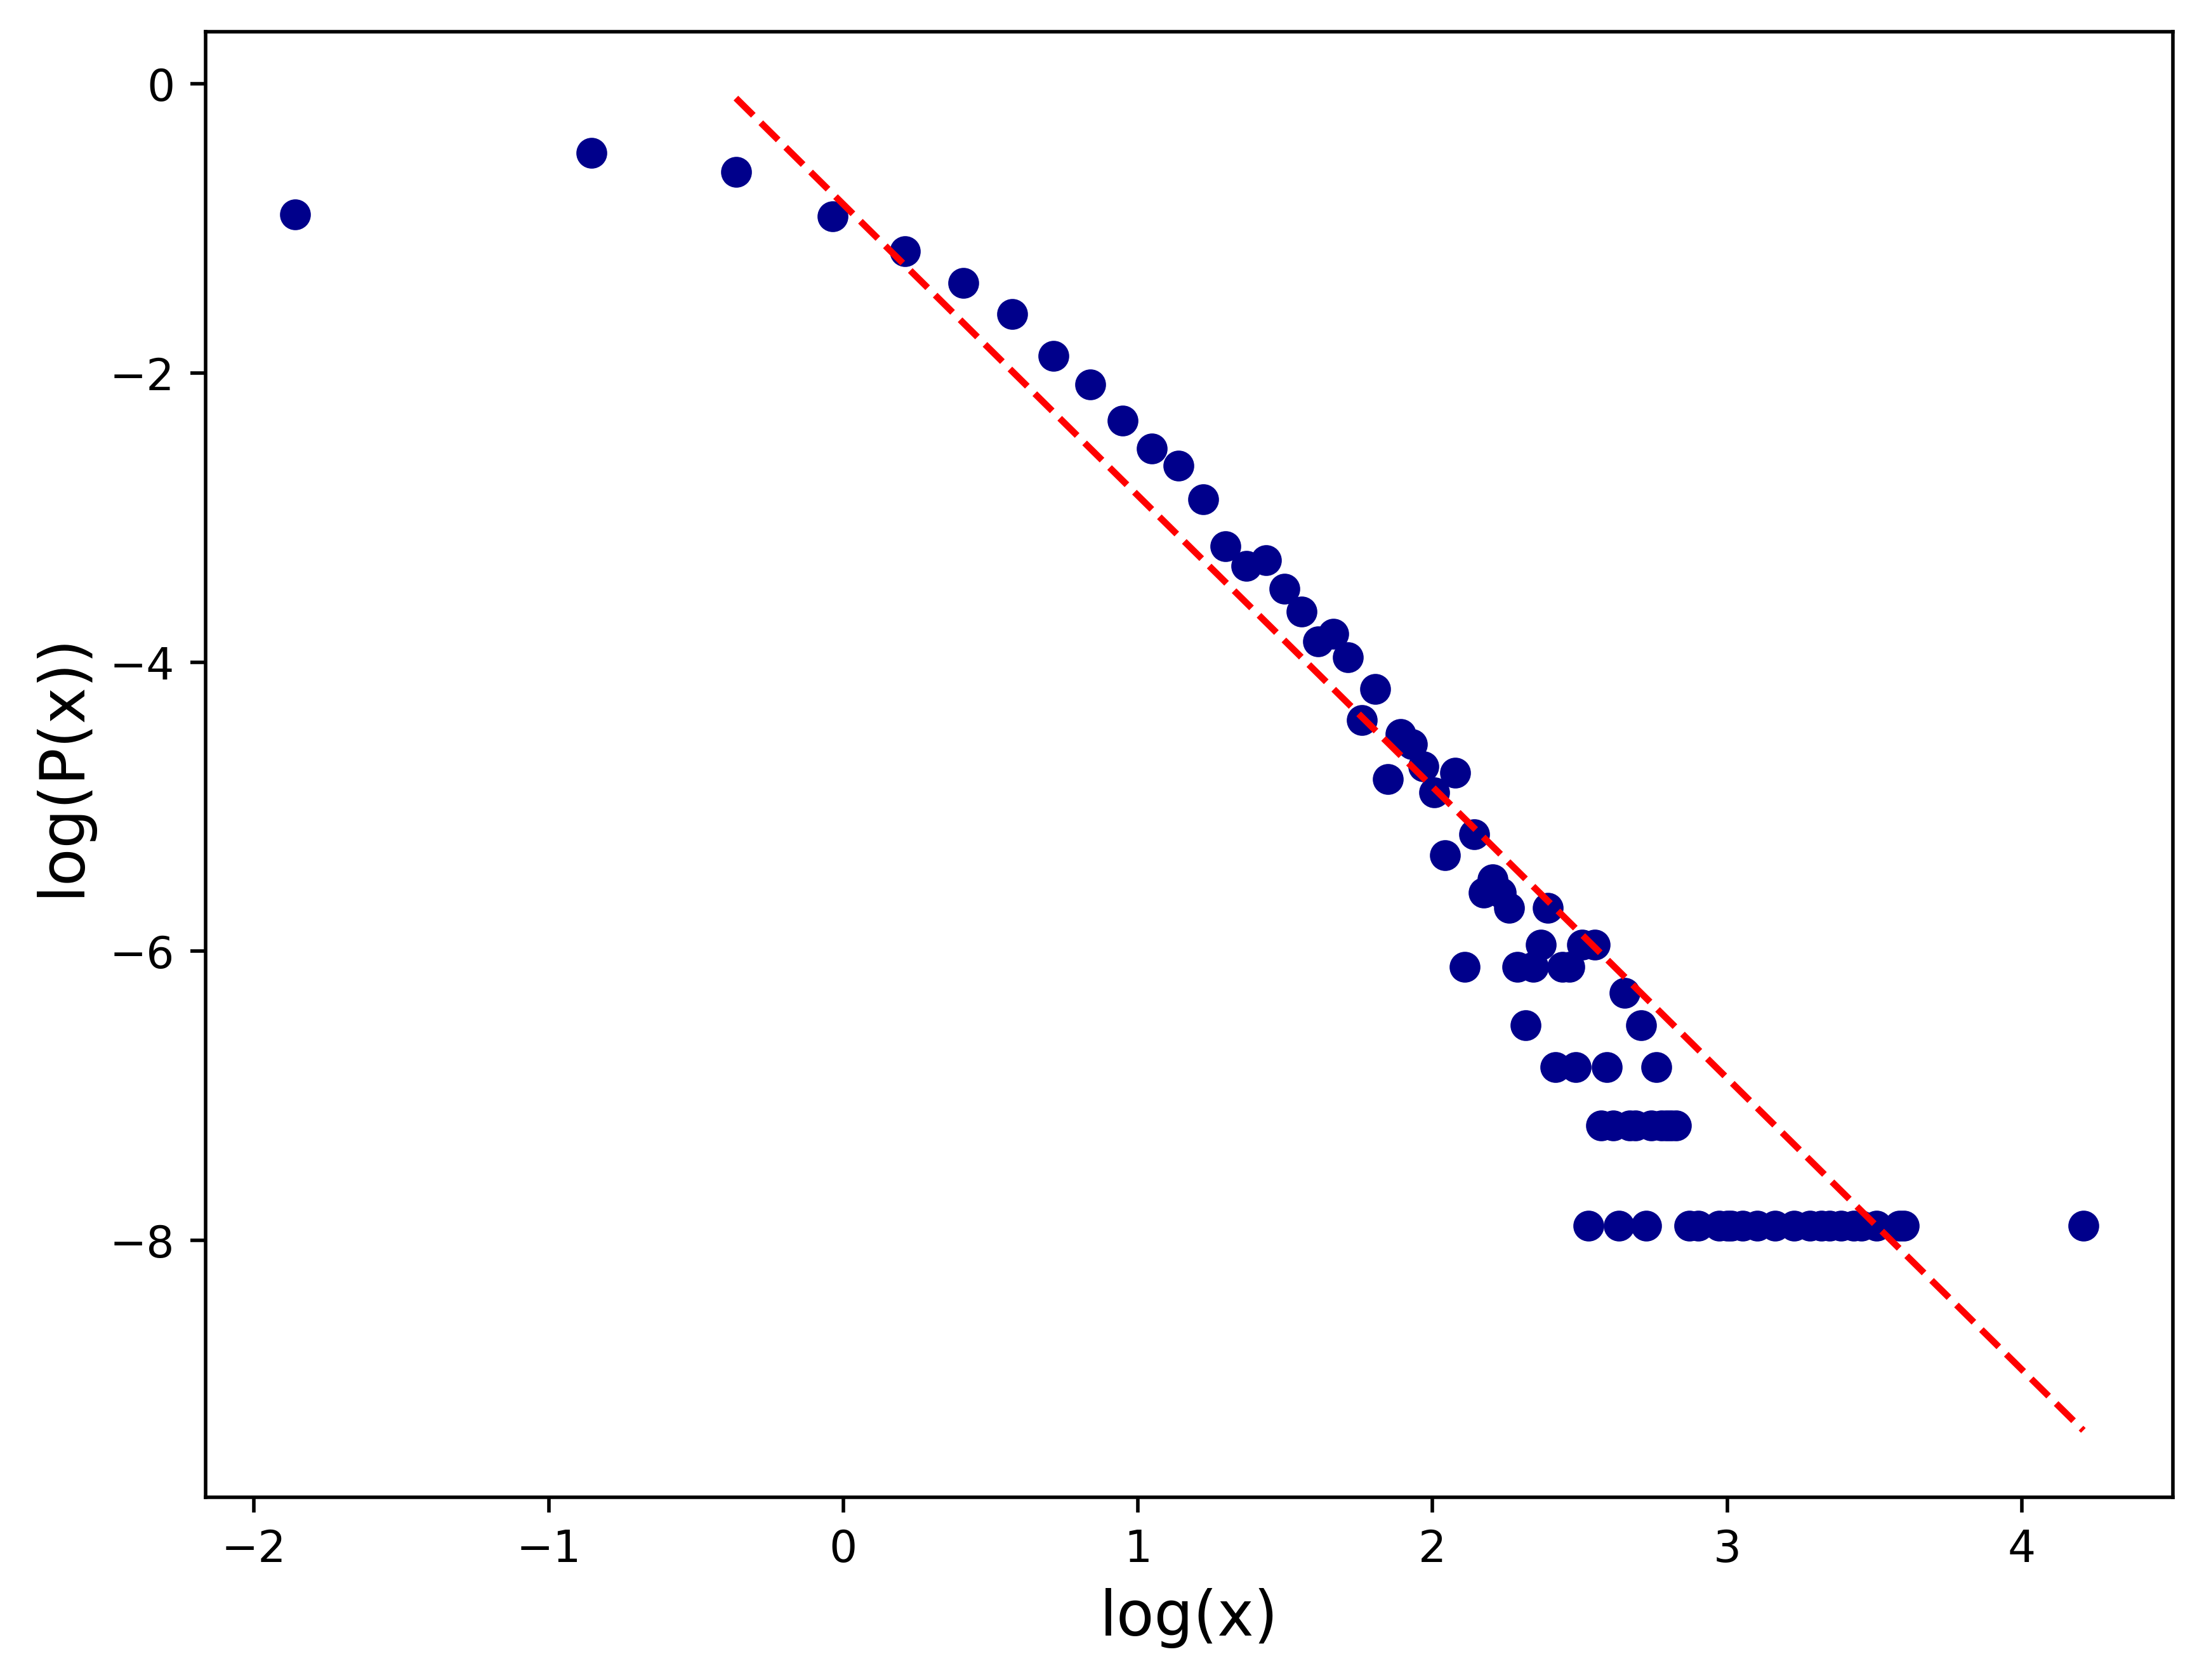

Slope: -2.015743446967869


In [41]:
# claimer: log-normal and power-law
mu, sigma = 0, 1
data = np.random.lognormal(mu, sigma, 10000)
count, bins, _ = plt.hist(data, bins=250, range=(min(data), max(data)), density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.close()
bin_centers = 0.5 * (bins[1:] + bins[:-1])
log_count = np.log(count[count > 0])
log_bin_centers = np.log(bin_centers[count > 0])

sorted_indices = np.argsort(log_bin_centers)
tail_975_indices = sorted_indices[int(0.025 * len(sorted_indices)):]
log_bin_centers_tail = log_bin_centers[tail_975_indices]
log_count_tail = log_count[tail_975_indices]
num_points = 1000
x_log_min, x_log_max = np.min(log_bin_centers_tail), np.max(log_bin_centers_tail)
uniform_log_bin_centers = np.linspace(x_log_min, x_log_max, num_points)
log_count_uniform = np.interp(uniform_log_bin_centers, log_bin_centers, log_count)

slope, intercept = np.polyfit(uniform_log_bin_centers, log_count_uniform, 1)
fit_line = slope * uniform_log_bin_centers + intercept

plt.figure(figsize=(8, 6), dpi=500)
plt.scatter(log_bin_centers, log_count, color='darkblue')
plt.plot(uniform_log_bin_centers, fit_line, linestyle='--', color='red')
plt.xlabel('log(x)', fontsize=14)
plt.ylabel('log(P(x))', fontsize=14)
plt.show()
print("Slope:", slope)

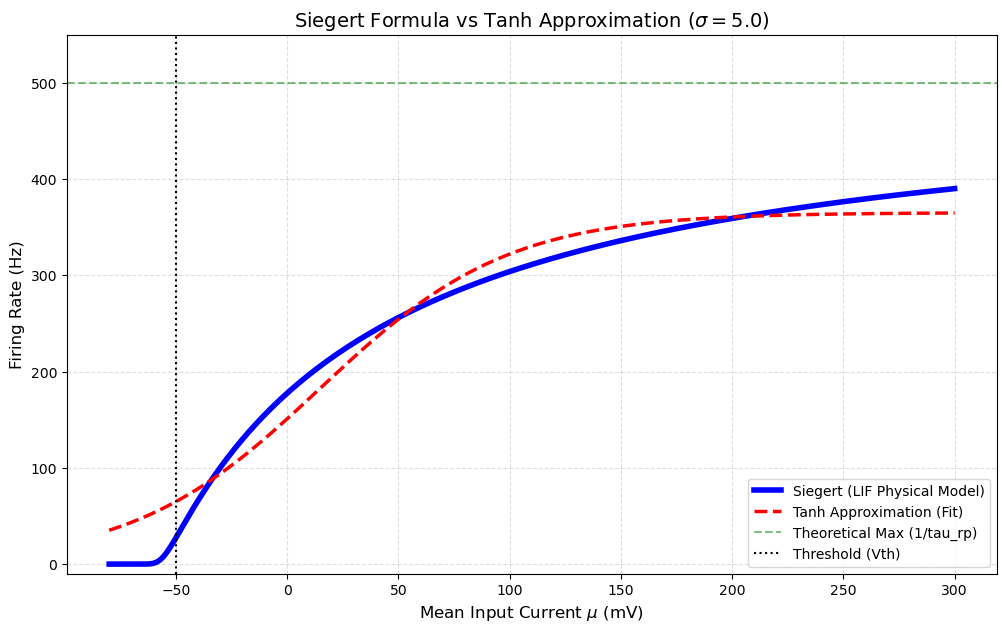

------------------------------
Tanh 拟合出的饱和极限: 365.20 Hz
Tanh 拟合出的中心偏置: 14.84 mV
------------------------------


In [51]:
# Siegert approximation using tanh
def stable_siegert(mu_range, sigma, tau_m=20.0, tau_rp=2.0, V_th=-50.0, V_res=-60.0):
    rates = []
    for mu in mu_range:
        # dimensionless unit
        u_th = (V_th - mu) / sigma
        u_res = (V_res - mu) / sigma
        
        integrand = lambda x: np.sqrt(np.pi) * erfcx(-x)
        integral, _ = quad(integrand, u_res, u_th)
        
        # nu = 1 / (tau_rp + tau_m * integral)
        rate = 1000.0 / (tau_rp + tau_m * integral) # the unit of 'tau' is ms
        rates.append(rate)
    return np.array(rates)

def tanh_approx(x, L, k, x0): # L: limit; k: slope; x0: center.
    return (L / 2) * (1 + np.tanh(k * (x - x0)))

# test parameters
sigma = 5.0 
mu_range = np.linspace(-80, 300, 250) 

y_siegert = stable_siegert(mu_range, sigma)

# fitting
popt, _ = curve_fit(tanh_approx, mu_range, y_siegert, p0=[500, 0.05, 0])
y_tanh = tanh_approx(mu_range, *popt)


plt.figure(figsize=(12, 7))
plt.plot(mu_range, y_siegert, 'b-', lw=4, label='Siegert (LIF Physical Model)')
plt.plot(mu_range, y_tanh, 'r--', lw=2.5, label=f'Tanh Approximation (Fit)')
plt.axhline(y=500, color='green', ls='--', alpha=0.5, label='Theoretical Max (1/tau_rp)')
plt.axvline(x=-50, color='black', ls=':', label='Threshold (Vth)')
plt.title(f'Siegert Formula vs Tanh Approximation ($\sigma={sigma}$)', fontsize=14)
plt.xlabel('Mean Input Current $\mu$ (mV)', fontsize=12)
plt.ylabel('Firing Rate (Hz)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.ylim(-10, 550)
plt.show()

print("-" * 30)
print(f"Tanh 拟合出的饱和极限: {popt[0]:.2f} Hz")
print(f"Tanh 拟合出的中心偏置: {popt[2]:.2f} mV")
print("-" * 30)